In [1]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   -------- ------------------------------- 2.4/10.7 MB 16.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.8/10.7 MB 16.0 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.7 MB 15.8 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 15.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from matplotlib import cm
from scipy.stats import entropy, gmean, kurtosis, skew

# 1. Loading the files and creating a data frame

In [3]:
# - Durchsucht Unterordner Z01 und Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks

440 files 
 Seminaraufgabe_2_Datei\sig\Z03\Z03_Pos06_RC2_75k_0000\Z03_Pos06_RC2_75k_0000_1307031507\Wav\Z03_Pos06_RC2_75k_0000_1307031507_00000_14_Ch1.wav


In [4]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')
    
    if len(parts) < 9:
        print("Unvollständiger Dateiname:", basename)
        continue  # Überspringen, wenn parts zu kurz ist

    sID = parts[8][:-4].strip()

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)
    
print(df['sID'].value_counts())


def compute_stft(sig, fs=1041667):
    f, t, Zxx = stft(sig, fs=fs, nperseg=1024)
    return (f, t, Zxx)

def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis

def analyze_stft(stft_data):
    f, t, Zxx = stft_data
    magnitude = np.abs(Zxx)
    mag_mean = np.mean(magnitude, axis=1)
    spectral_mean = np.sum(f * mag_mean) / np.sum(mag_mean)
    spectral_variance = np.sum(((f - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean)

    upper_half = mag_mean[len(f)//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist)
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half)
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = f[rolloff_idx]
    kurt_upper = kurtosis(upper_half)

    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper

def extract_all_features(sig, stft_data, suffix=''):
    sm, sv, ss, srms, sp, sk = analyze_signal(sig)
    spm, spv, se, sf, sr, skurt = analyze_stft(stft_data)

    return {
        f'sig_mean{suffix}': sm,
        f'sig_var{suffix}': sv,
        f'sig_skew{suffix}': ss,
        f'sig_rms{suffix}': srms,
        f'sig_peak{suffix}': sp,
        f'sig_kurtosis{suffix}': sk,
        f'spec_mean{suffix}': spm,
        f'spec_var{suffix}': spv,
        f'spec_entropy_up{suffix}': se,
        f'spec_flatness{suffix}': sf,
        f'spec_rolloff_freq{suffix}': sr,
        f'spec_kurtosis{suffix}': skurt
    }



sID
Ch1    220
Ch2    220
Name: count, dtype: int64


# 2. Separate channels

In [5]:
df['sID'] = df['sID'].astype(str).str.strip()
df_ch1 = df[df['sID'] == 'Ch1'].copy()
df_ch2 = df[df['sID'] == 'Ch2'].copy()

merge_keys = ['spec', 'mID', 'time', 'rID']

df_merged = pd.merge(
    df_ch1[['spec', 'mID', 'time', 'rID', 'sig']],
    df_ch2[['spec', 'mID', 'time', 'rID', 'sig']],
    on=merge_keys,
    suffixes=('_ch1', '_ch2')
)


display(df_ch1)
display(df_ch2)

,fn,sig,spec,mID,time,rID,sID,stft
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",Z01,0000,1307031427,00000,Ch1,None
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",Z01,0000,1307031427,00001,Ch1,None
4,Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...,"[0.00048828125, 0.00146484375, 0.00048828125, ...",Z01,0001,1312091511,00000,Ch1,None
6,Z01_Pos00_RC2_75k_0001_1312091511_00001_14_Ch1...,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...",Z01,0001,1312091511,00001,Ch1,None
8,Z01_Pos00_RC2_75k_0002_1312101402_00000_14_Ch1...,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...",Z01,0002,1312101402,00000,Ch1,None
...,...,...,...,...,...,...,...,...
430,Z05_Pos07_RC2_75k_0000_1307031539_00001_14_Ch1...,"[0.00048828125, 0.0009765625, 0.001953125, 0.0...",Z05,0000,1307031539,00001,Ch1,None
432,Z05_Pos08_RC2_75k_0000_1307031539_00000_14_Ch1...,"[0.001953125, 0.00146484375, 0.00048828125, 0....",Z05,0000,1307031539,00000,Ch1,None
434,Z05_Pos08_RC2_75k_0000_1307031539_00001_14_Ch1...,"[0.0048828125, 0.001953125, 0.0009765625, 0.00...",Z05,0000,1307031539,00001,Ch1,None
436,Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch1...,"[0.0029296875, 0.00244140625, 0.00146484375, 0...",Z05,0000,1307031540,00000,Ch1,None


,fn,sig,spec,mID,time,rID,sID,stft
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",Z01,0000,1307031427,00000,Ch2,None
3,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...,"[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",Z01,0000,1307031427,00001,Ch2,None
5,Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch2...,"[0.00048828125, 0.0009765625, 0.001953125, 0.0...",Z01,0001,1312091511,00000,Ch2,None
7,Z01_Pos00_RC2_75k_0001_1312091511_00001_14_Ch2...,"[0.00048828125, 0.0, 0.0009765625, 0.000976562...",Z01,0001,1312091511,00001,Ch2,None
9,Z01_Pos00_RC2_75k_0002_1312101402_00000_14_Ch2...,"[0.00048828125, -0.0009765625, 0.0, 0.00097656...",Z01,0002,1312101402,00000,Ch2,None
...,...,...,...,...,...,...,...,...
431,Z05_Pos07_RC2_75k_0000_1307031539_00001_14_Ch2...,"[0.00244140625, 0.00048828125, 0.00048828125, ...",Z05,0000,1307031539,00001,Ch2,None
433,Z05_Pos08_RC2_75k_0000_1307031539_00000_14_Ch2...,"[0.0009765625, -0.0009765625, 0.0, 0.001464843...",Z05,0000,1307031539,00000,Ch2,None
435,Z05_Pos08_RC2_75k_0000_1307031539_00001_14_Ch2...,"[0.0, 0.00244140625, 0.00146484375, 0.00097656...",Z05,0000,1307031539,00001,Ch2,None
437,Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch2...,"[0.00048828125, -0.00048828125, 0.0009765625, ...",Z05,0000,1307031540,00000,Ch2,None


# 3. Feature extraction

In [6]:
features = []

for idx, row in df_merged.iterrows():
    sig1 = row['sig_ch1']
    sig2 = row['sig_ch2']

    stft1 = compute_stft(sig1)
    stft2 = compute_stft(sig2)

    f1 = extract_all_features(sig1, stft1, suffix='_ch1')
    f2 = extract_all_features(sig2, stft2, suffix='_ch2')

    features.append({**row.to_dict(), **f1, **f2})

df_features = pd.DataFrame(features)
print(df_features.shape)
display(df_features.head())


(392, 30)


,spec,mID,time,rID,sig_ch1,sig_ch2,sig_mean_ch1,sig_var_ch1,sig_skew_ch1,sig_rms_ch1,...,sig_skew_ch2,sig_rms_ch2,sig_peak_ch2,sig_kurtosis_ch2,spec_mean_ch2,spec_var_ch2,spec_entropy_up_ch2,spec_flatness_ch2,spec_rolloff_freq_ch2,spec_kurtosis_ch2
0,Z01,0000,1307031427,00000,"[0.00048828125, 0.00244140625, 0.0029296875, 0...","[0.001953125, 0.0, 0.00146484375, 0.001953125,...",0.001518,0.000824,-0.020609,0.028749,...,-0.173273,0.039612,0.457214,16.392937,57570.166639,9.592240e+09,5.217694,0.815069,59000.669922,77.143177
1,Z01,0000,1307031427,00001,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...","[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",0.001247,0.000837,0.003026,0.028963,...,-0.145501,0.040230,0.465515,16.315769,54821.522639,8.804397e+09,5.252934,0.852287,57983.416992,100.542796
2,Z01,0001,1312091511,00000,"[0.00048828125, 0.00146484375, 0.00048828125, ...","[0.00048828125, 0.0009765625, 0.001953125, 0.0...",0.000970,0.000561,0.035185,0.023708,...,-0.125625,0.033959,0.398102,18.489491,57202.157464,9.179451e+09,5.376821,0.918173,62052.428711,124.740067
3,Z01,0001,1312091511,00001,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...","[0.00048828125, 0.0, 0.0009765625, 0.000976562...",0.000843,0.000567,0.026321,0.023826,...,-0.140516,0.034761,0.404480,18.523465,57238.206669,9.178731e+09,5.380707,0.917318,61035.175781,123.687647
4,Z01,0002,1312101402,00000,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...","[0.00048828125, -0.0009765625, 0.0, 0.00097656...",0.000748,0.000657,-0.003974,0.025645,...,-0.142080,0.040355,0.509003,20.519258,52919.188720,7.915353e+09,5.304285,0.890652,56966.164062,125.968764


In [7]:
featureslist = ['sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis' 'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis']  # added new features
for i in featureslist:
    df[i] = None

In [8]:
df_ch1_features = df_features[[col for col in df_features.columns if col.endswith('_ch1')]].copy()
df_ch2_features = df_features[[col for col in df_features.columns if col.endswith('_ch2')]].copy()

df_ch1_features['spec'] = df_features['spec'] 
df_ch2_features['spec'] = df_features['spec']


display(df_ch1_features)
display(df_ch2_features)


,sig_ch1,sig_mean_ch1,sig_var_ch1,sig_skew_ch1,sig_rms_ch1,sig_peak_ch1,sig_kurtosis_ch1,spec_mean_ch1,spec_var_ch1,spec_entropy_up_ch1,spec_flatness_ch1,spec_rolloff_freq_ch1,spec_kurtosis_ch1,spec
0,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",0.001518,0.000824,-0.020609,0.028749,0.272095,16.887122,62229.191212,1.160921e+10,5.325770,0.862661,86466.499023,55.035126,Z01
1,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",0.001247,0.000837,0.003026,0.028963,0.274536,16.867039,58843.744252,1.068535e+10,5.375108,0.904144,82397.487305,94.307794,Z01
2,"[0.00048828125, 0.00146484375, 0.00048828125, ...",0.000970,0.000561,0.035185,0.023708,0.245697,16.344766,63521.590551,1.164219e+10,5.376269,0.919195,89518.257812,125.219816,Z01
3,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...",0.000843,0.000567,0.026321,0.023826,0.244232,16.194716,63310.298139,1.155657e+10,5.377219,0.918931,89518.257812,127.244299,Z01
4,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...",0.000748,0.000657,-0.003974,0.025645,0.254486,15.596158,61573.362504,1.112655e+10,5.383362,0.921998,86466.499023,128.383100,Z01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,"[0.001953125, 0.00146484375, 0.00048828125, 0....",0.001393,0.000388,0.118191,0.019746,0.244232,27.112386,81108.217975,1.670667e+10,5.349879,0.875002,218709.379883,52.817822,Z05
388,"[0.0048828125, 0.001953125, 0.0009765625, 0.00...",0.001826,0.000383,0.147824,0.019648,0.241791,27.324330,79929.270560,1.647466e+10,5.348364,0.874659,214640.368164,52.250561,Z05
389,"[0.0048828125, 0.001953125, 0.0009765625, 0.00...",0.001826,0.000383,0.147824,0.019648,0.241791,27.324330,79929.270560,1.647466e+10,5.348364,0.874659,214640.368164,52.250561,Z05
390,"[0.0029296875, 0.00244140625, 0.00146484375, 0...",0.001037,0.000353,-0.368753,0.018824,0.310669,37.879398,88869.921457,1.805926e+10,5.349552,0.875648,253295.979492,52.760196,Z05


,sig_ch2,sig_mean_ch2,sig_var_ch2,sig_skew_ch2,sig_rms_ch2,sig_peak_ch2,sig_kurtosis_ch2,spec_mean_ch2,spec_var_ch2,spec_entropy_up_ch2,spec_flatness_ch2,spec_rolloff_freq_ch2,spec_kurtosis_ch2,spec
0,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",0.001020,0.001568,-0.173273,0.039612,0.457214,16.392937,57570.166639,9.592240e+09,5.217694,0.815069,59000.669922,77.143177,Z01
1,"[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",0.000738,0.001618,-0.145501,0.040230,0.465515,16.315769,54821.522639,8.804397e+09,5.252934,0.852287,57983.416992,100.542796,Z01
2,"[0.00048828125, 0.0009765625, 0.001953125, 0.0...",0.001135,0.001152,-0.125625,0.033959,0.398102,18.489491,57202.157464,9.179451e+09,5.376821,0.918173,62052.428711,124.740067,Z01
3,"[0.00048828125, 0.0, 0.0009765625, 0.000976562...",0.000993,0.001207,-0.140516,0.034761,0.404480,18.523465,57238.206669,9.178731e+09,5.380707,0.917318,61035.175781,123.687647,Z01
4,"[0.00048828125, -0.0009765625, 0.0, 0.00097656...",0.000368,0.001628,-0.142080,0.040355,0.509003,20.519258,52919.188720,7.915353e+09,5.304285,0.890652,56966.164062,125.968764,Z01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,"[0.0009765625, -0.0009765625, 0.0, 0.001464843...",0.000891,0.000949,-0.626406,0.030823,0.496307,42.570642,73107.780912,1.387748e+10,5.234440,0.822385,153605.192383,74.975339,Z05
388,"[0.00244140625, 0.00048828125, 0.00048828125, ...",0.001165,0.000886,0.430376,0.029794,0.501190,44.740018,76907.866301,1.449809e+10,5.242968,0.830719,175984.756836,84.760469,Z05
389,"[0.0, 0.00244140625, 0.00146484375, 0.00097656...",0.001310,0.000941,-0.626287,0.030710,0.494354,43.023660,70594.092466,1.327960e+10,5.251416,0.838257,132242.880859,89.368786,Z05
390,"[0.00048828125, -0.00048828125, 0.0009765625, ...",0.000501,0.000599,0.106331,0.024475,0.380035,44.140591,88218.274748,1.671108e+10,5.220715,0.812240,234985.426758,68.742116,Z05


# 4. Feature Overview

## 4.1 Boxplot: comparison of characteristics between channels

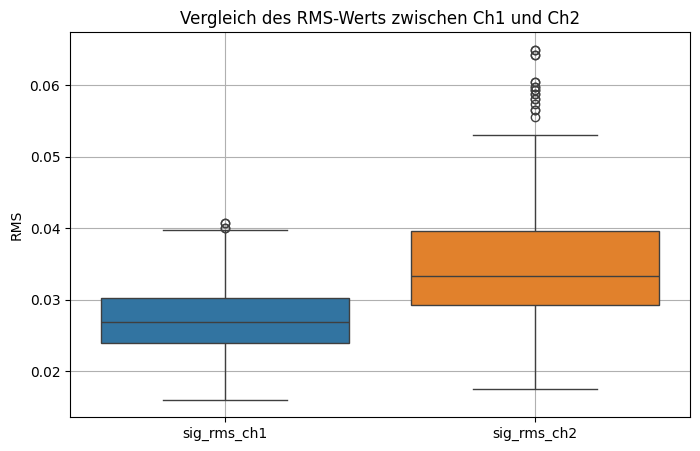

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_features[['sig_rms_ch1', 'sig_rms_ch2']])
plt.title('Vergleich des RMS-Werts zwischen Ch1 und Ch2')
plt.ylabel('RMS')
plt.grid()
plt.show()

## 4.2 Scatter Plot: comparison of two characteristics 
spectral_mean vs. spectral_flatness — one channel at a time.


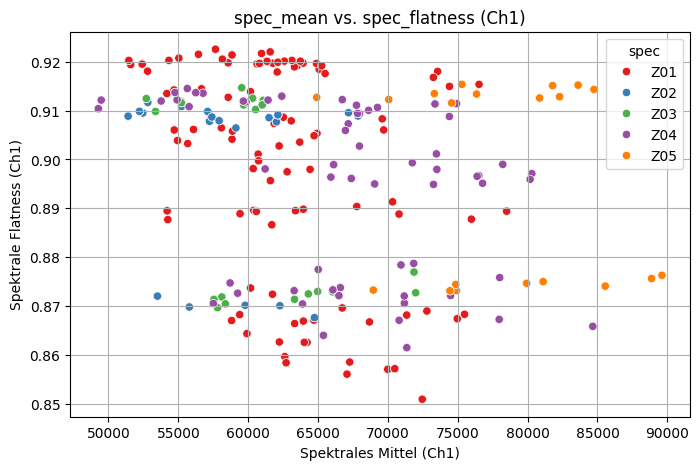

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_features,
    x='spec_mean_ch1', 
    y='spec_flatness_ch1', 
    hue='spec',  
    palette='Set1'
)
plt.title('spec_mean vs. spec_flatness (Ch1)')
plt.xlabel('Spektrales Mittel (Ch1)')
plt.ylabel('Spektrale Flatness (Ch1)')
plt.grid()
plt.show()

## 4.3 Histogram: distribution of a single characteristic

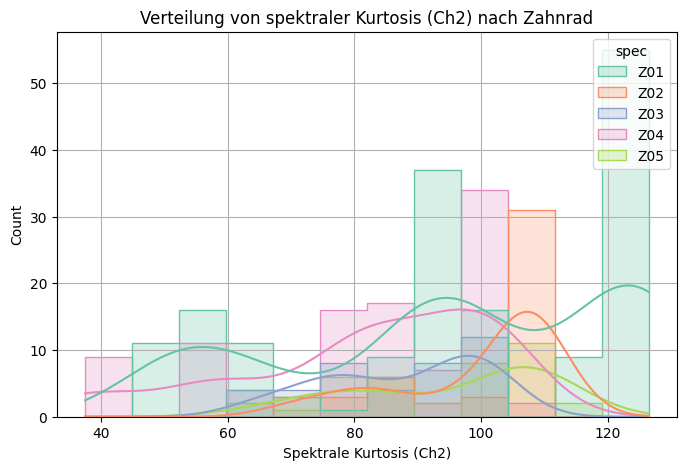

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_features, x='spec_kurtosis_ch2', hue='spec', kde=True, element='step', palette='Set2')
plt.title('Verteilung von spektraler Kurtosis (Ch2) nach Zahnrad')
plt.xlabel('Spektrale Kurtosis (Ch2)')
plt.grid()
plt.show()

## 4.4 Pairplot (Seaborn): clustering by characteristics

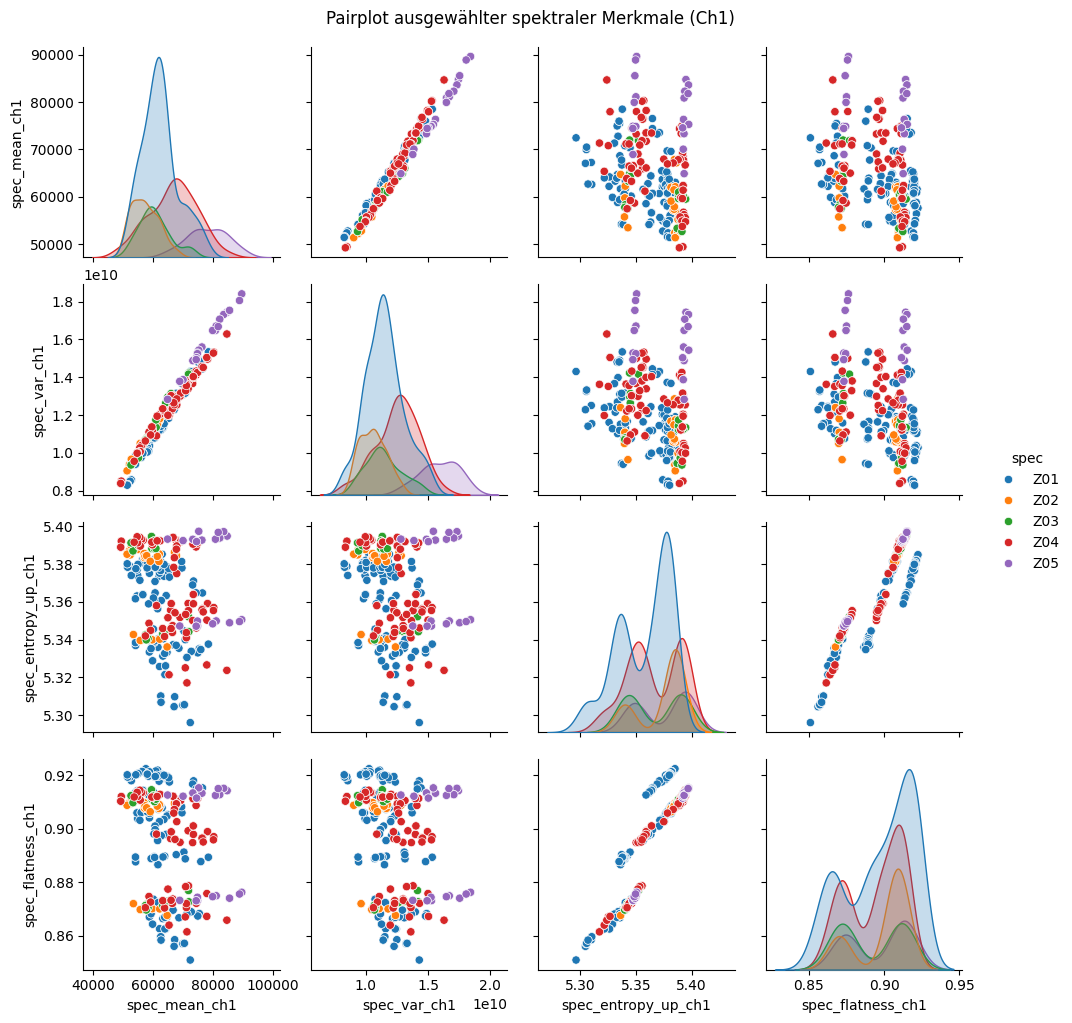

In [12]:
selected = ['spec_mean_ch1', 'spec_var_ch1', 'spec_entropy_up_ch1', 'spec_flatness_ch1']
sns.pairplot(df_features[selected + ['spec']], hue='spec', palette='tab10')
plt.suptitle('Pairplot ausgewählter spektraler Merkmale (Ch1)', y=1.02)
plt.show()

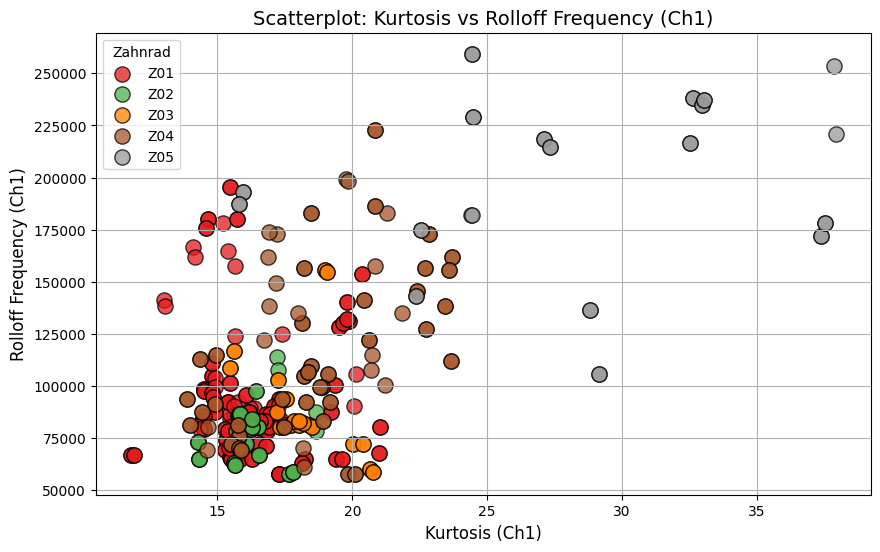

In [13]:
colors = plt.cm.Set1(np.linspace(0, 1, 5))
spec_labels = sorted(df_ch1_features['spec'].unique())
color_map = {label: colors[i] for i, label in enumerate(spec_labels)}

plt.figure(figsize=(10, 6))
for label in spec_labels:
    mask = df_ch1_features['spec'] == label
    plt.scatter(
        df_ch1_features.loc[mask, 'sig_kurtosis_ch1'],
        df_ch1_features.loc[mask, 'spec_rolloff_freq_ch1'],
        label=label,
        c=color_map[label].reshape(1, -1),
        edgecolors='k',
        alpha=0.75,
        s=120
    )

plt.grid(True)
plt.title("Scatterplot: Kurtosis vs Rolloff Frequency (Ch1)", fontsize=14)
plt.xlabel("Kurtosis (Ch1)", fontsize=12)
plt.ylabel("Rolloff Frequency (Ch1)", fontsize=12)
plt.legend(title="Zahnrad", loc="best")
plt.show()


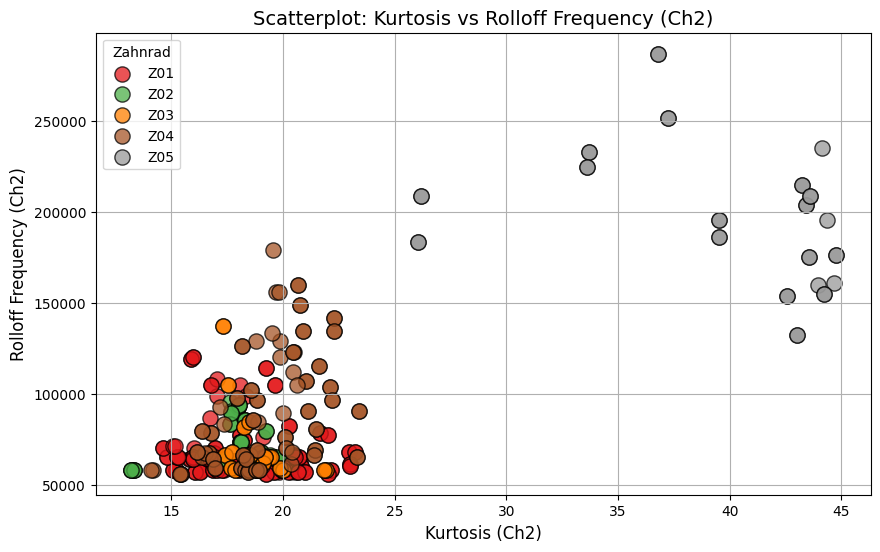

In [14]:
colors = plt.cm.Set1(np.linspace(0, 1, 5))
spec_labels = sorted(df_ch2_features['spec'].unique())
color_map = {label: colors[i] for i, label in enumerate(spec_labels)}

plt.figure(figsize=(10, 6))
for label in spec_labels:
    mask = df_ch2_features['spec'] == label
    plt.scatter(
        df_ch2_features.loc[mask, 'sig_kurtosis_ch2'],
        df_ch2_features.loc[mask, 'spec_rolloff_freq_ch2'],
        label=label,
        c=color_map[label].reshape(1, -1),
        edgecolors='k',
        alpha=0.75,
        s=120
    )

plt.grid(True)
plt.title("Scatterplot: Kurtosis vs Rolloff Frequency (Ch2)", fontsize=14)
plt.xlabel("Kurtosis (Ch2)", fontsize=12)
plt.ylabel("Rolloff Frequency (Ch2)", fontsize=12)
plt.legend(title="Zahnrad", loc="best")
plt.show()


In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def correlation_matrix(df, title="Feature Correlation Matrix"):
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111)

    cmap = plt.colormaps.get_cmap('coolwarm')

    cax = ax.imshow(df.corr(), interpolation="nearest", cmap=cmap, vmin=-1, vmax=1)
    ax.grid(True)
    plt.title(title, fontsize=15)
    labels = df.columns
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    fig.colorbar(cax)
    plt.tight_layout()
    plt.show()


In [16]:
df_long = pd.DataFrame({
    'RMS': np.concatenate([df_ch1_features['sig_rms_ch1'], df_ch2_features['sig_rms_ch2']]),
    'Flatness': np.concatenate([df_ch1_features['spec_flatness_ch1'], df_ch2_features['spec_flatness_ch2']]),
    'Channel': ['Ch1'] * len(df_ch1_features) + ['Ch2'] * len(df_ch2_features)
})

C:\Users\OsenD\AppData\Local\Temp\ipykernel_6868\607437565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Channel', y='RMS', data=df_long, palette='Set2')


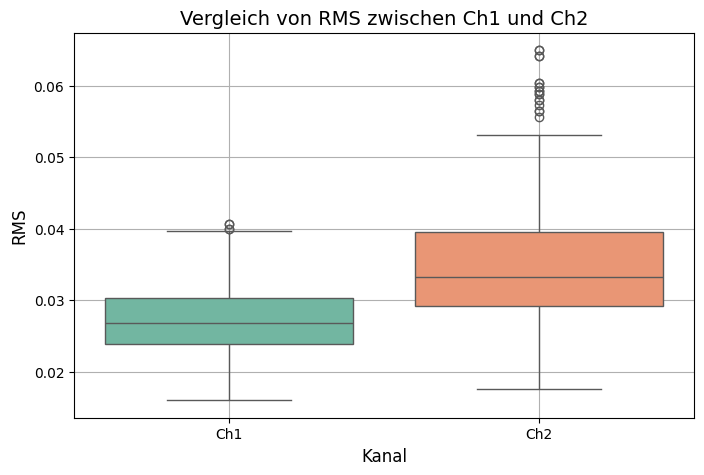

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Channel', y='RMS', data=df_long, palette='Set2')
plt.title('Vergleich von RMS zwischen Ch1 und Ch2', fontsize=14)
plt.ylabel('RMS', fontsize=12)
plt.xlabel('Kanal', fontsize=12)
plt.grid()
plt.show()

C:\Users\OsenD\AppData\Local\Temp\ipykernel_6868\2147272270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Channel', y='Flatness', data=df_long, palette='Set1')


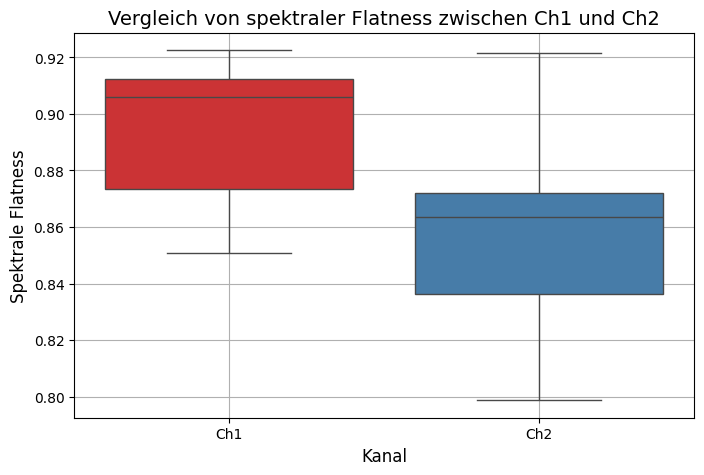

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Channel', y='Flatness', data=df_long, palette='Set1')
plt.title('Vergleich von spektraler Flatness zwischen Ch1 und Ch2', fontsize=14)
plt.ylabel('Spektrale Flatness', fontsize=12)
plt.xlabel('Kanal', fontsize=12)
plt.grid()
plt.show()

## 5. Unterteilen Sie die Z01–Z05-Daten in 3 Mengen (Train / Dev / Test)

In [19]:
from sklearn.model_selection import train_test_split

# 1 = gut, 0 = defekt
df_ch1_features['label'] = df_ch1_features['spec'].apply(lambda x: 0 if x == 'Z05' else 1)
df_ch2_features['label'] = df_ch2_features['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# === CHANNEL 1 ===
# Full dataset
X_full_ch1 = df_ch1_features.copy()

# Stratified Split: 60% train, 20% dev, 20% test
train_ch1, temp_ch1 = train_test_split(X_full_ch1, test_size=0.4, stratify=X_full_ch1['label'], random_state=42)
dev_ch1, test_ch1 = train_test_split(temp_ch1, test_size=0.5, stratify=temp_ch1['label'], random_state=42)

# === CHANNEL 2 ===
X_full_ch2 = df_ch2_features.copy()

train_ch2, temp_ch2 = train_test_split(X_full_ch2, test_size=0.4, stratify=X_full_ch2['label'], random_state=42)
dev_ch2, test_ch2 = train_test_split(temp_ch2, test_size=0.5, stratify=temp_ch2['label'], random_state=42)

# === Kontrollausgabe ===
print("CH1:")
print("Train:", train_ch1.shape)
print("Dev:", dev_ch1.shape)
print("Test:", test_ch1.shape)
print("Train Label Count:\n", train_ch1['label'].value_counts())
print("Dev Label Count:\n", dev_ch1['label'].value_counts())
print("Test Label Count:\n", test_ch1['label'].value_counts())

print("\nCH2:")
print("Train:", train_ch2.shape)
print("Dev:", dev_ch2.shape)
print("Test:", test_ch2.shape)
print("Train Label Count:\n", train_ch2['label'].value_counts())
print("Dev Label Count:\n", dev_ch2['label'].value_counts())
print("Test Label Count:\n", test_ch2['label'].value_counts())


CH1:
Train: (235, 15)
Dev: (78, 15)
Test: (79, 15)
Train Label Count:
 label
1    213
0     22
Name: count, dtype: int64
Dev Label Count:
 label
1    71
0     7
Name: count, dtype: int64
Test Label Count:
 label
1    72
0     7
Name: count, dtype: int64

CH2:
Train: (235, 15)
Dev: (78, 15)
Test: (79, 15)
Train Label Count:
 label
1    213
0     22
Name: count, dtype: int64
Dev Label Count:
 label
1    71
0     7
Name: count, dtype: int64
Test Label Count:
 label
1    72
0     7
Name: count, dtype: int64


## 6. Finden Sie den am besten geeigneten Ansatz zur Merkmalsanalyse

## 6.1 Feature Importance (Channel 1)

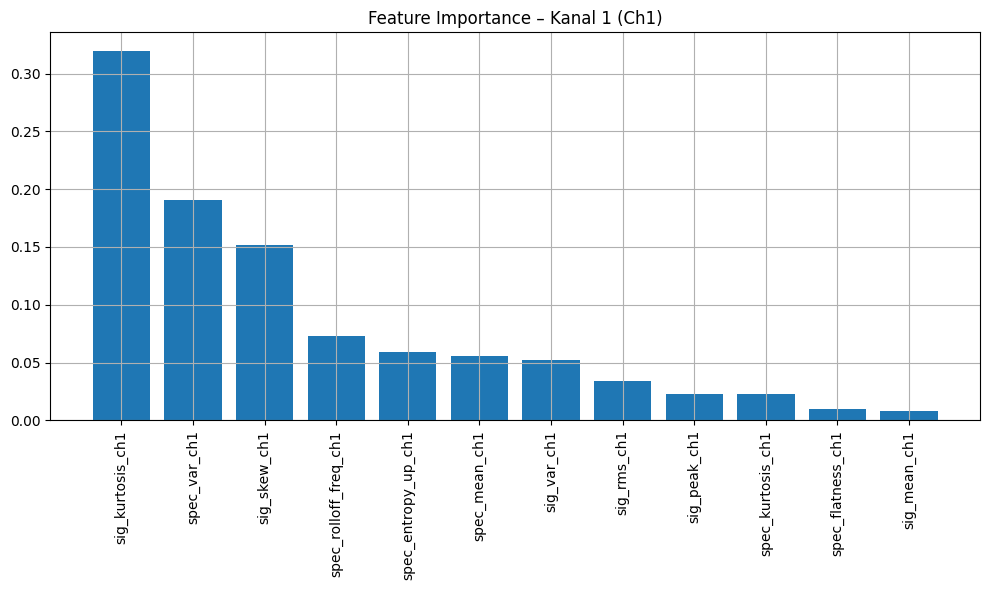

Top-3 Features Ch1: ['sig_kurtosis_ch1', 'spec_var_ch1', 'sig_skew_ch1']


In [20]:
from sklearn.ensemble import RandomForestClassifier

df_ch1 = df_ch1_features.copy()
df_ch1['label'] = df_ch1['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

X_ch1 = df_ch1.drop(columns=['spec', 'label']).select_dtypes(include=[np.number])
y_ch1 = df_ch1['label']

rf_ch1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ch1.fit(X_ch1, y_ch1)

importances_ch1 = rf_ch1.feature_importances_
indices_ch1 = np.argsort(importances_ch1)[::-1]
top_features_ch1 = X_ch1.columns[indices_ch1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance – Kanal 1 (Ch1)")
plt.bar(range(len(importances_ch1)), importances_ch1[indices_ch1], align='center')
plt.xticks(range(len(importances_ch1)), top_features_ch1, rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

print("Top-3 Features Ch1:", top_features_ch1[:3].tolist())

## 6.2 Feature Importance (Channel 2)

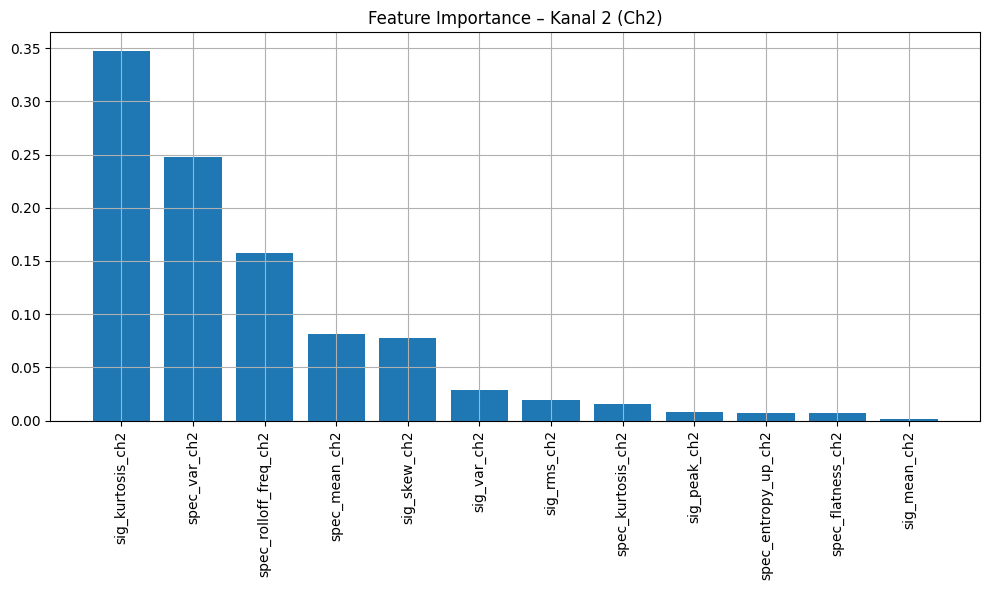

Top-3 Features Ch2: ['sig_kurtosis_ch2', 'spec_var_ch2', 'spec_rolloff_freq_ch2']


In [21]:
df_ch2 = df_ch2_features.copy()
df_ch2['label'] = df_ch2['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

X_ch2 = df_ch2.drop(columns=['spec', 'label']).select_dtypes(include=[np.number])
y_ch2 = df_ch2['label']

rf_ch2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ch2.fit(X_ch2, y_ch2)

importances_ch2 = rf_ch2.feature_importances_
indices_ch2 = np.argsort(importances_ch2)[::-1]
top_features_ch2 = X_ch2.columns[indices_ch2]

plt.figure(figsize=(10,6))
plt.title("Feature Importance – Kanal 2 (Ch2)")
plt.bar(range(len(importances_ch2)), importances_ch2[indices_ch2], align='center')
plt.xticks(range(len(importances_ch2)), top_features_ch2, rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

print("Top-3 Features Ch2:", top_features_ch2[:3].tolist())

## 7. Training von Modell beim Benutzen der 3 wichtigsten Merkmalen

Wir verwenden StandardScaler von sklearn, und bereiten X_train, X_dev, X_test sowie y_train usw. vor.


## 7.1 Channel 1

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Beste Parameter (DEV-basiert): {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 16, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01, 'max_iter': 500, 'solver': 'adam'}
Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.97      1.00      0.99        72

    accuracy                           0.97        79
   macro avg       0.99      0.86      0.91        79
weighted avg       0.98      0.97      0.97        79



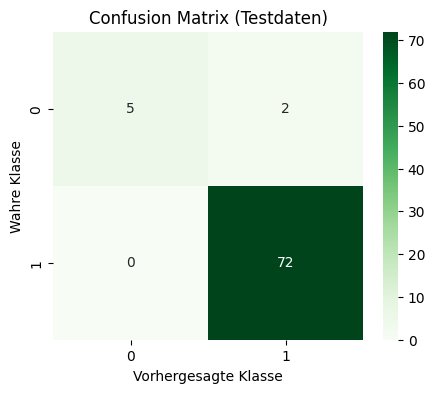

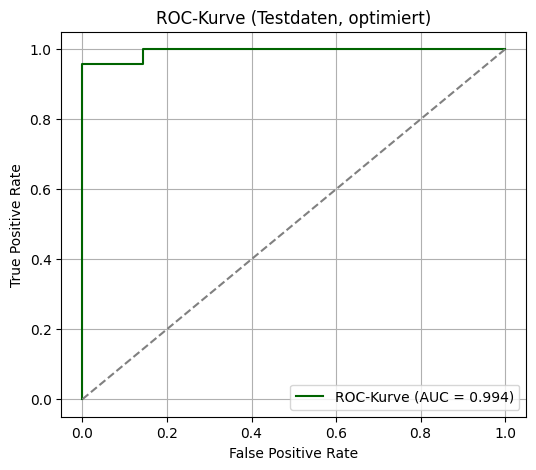

ROC-AUC Score (Testdaten): 0.994


In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 Top 3 Features (Kanal 1)
top3_ch1_features = ['spec_kurtosis_ch1', 'spec_var_ch1', 'spec_mean_ch1']

# Trainings-, Entwicklungs- und Testdaten
X_train = train_ch1[top3_ch1_features]
y_train = train_ch1['label']
X_dev = dev_ch1[top3_ch1_features]
y_dev = dev_ch1['label']
X_test = test_ch1[top3_ch1_features]
y_test = test_ch1['label']

# Standardisierung der Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.05],
    'batch_size': [8, 16, 32],
    'max_iter': [500],
    'solver': ['adam'],
    'activation': ['relu']
}

mlp_base = MLPClassifier(random_state=42)

# GridSearch auf dem DEV-Set
grid = GridSearchCV(mlp_base, param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
grid.fit(X_dev_scaled, y_dev)

print("Beste Parameter (DEV-basiert):", grid.best_params_)

# Trainiere bestes Modell auf TRAIN
best_mlp = grid.best_estimator_
best_mlp.fit(X_train_scaled, y_train)

# Vorhersage auf TEST
y_pred = best_mlp.predict(X_test_scaled)
y_proba = best_mlp.predict_proba(X_test_scaled)[:, 1]

# Klassifikationsbericht
print("Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Testdaten)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Wahre Klasse')
plt.show()

# ROC-Kurve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-Kurve (AUC = {auc_score:.3f})', color='darkgreen')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve (Testdaten, optimiert)')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC Score (Testdaten): {auc_score:.3f}")


## 7.2 Channel 2

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameters (from DEV set): {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 8, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.98      0.98      0.98        85

    accuracy                           0.96       106
   macro avg       0.94      0.94      0.94       106
weighted avg       0.96      0.96      0.96       106



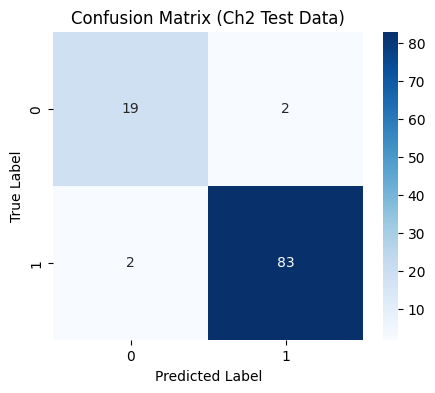

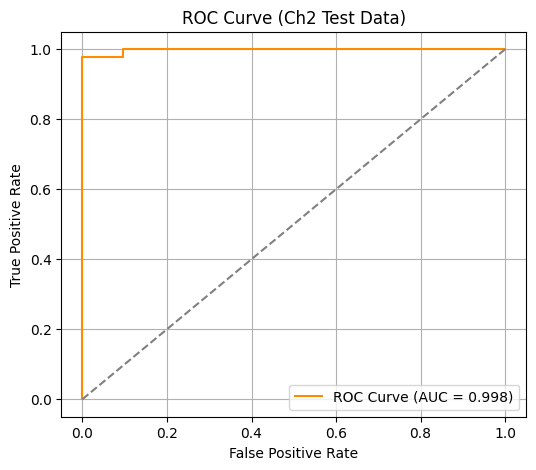

ROC-AUC Score: 0.998


In [23]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Assign label: 1 = good (Z01–Z04), 0 = defective (Z05)
top3_ch2_features = ['spec_kurtosis_ch2', 'spec_var_ch2', 'spec_rolloff_freq_ch2']

# build dataset
df_ch2_features['label'] = df_ch2_features['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Select train/dev/test splits based on predefined subsets
z04 = df_ch2_features[df_ch2_features['spec'] == 'Z04']
z05 = df_ch2_features[df_ch2_features['spec'] == 'Z05']

z04_dev, z04_test = train_test_split(z04, train_size=15, random_state=42)
z05_dev, z05_test = train_test_split(z05, train_size=15, random_state=42)

dev = pd.concat([z04_dev, z05_dev], ignore_index=True)
test = pd.concat([z04_test, z05_test], ignore_index=True)

dev = shuffle(dev, random_state=42)
test = shuffle(test, random_state=42)

X_train = train_ch2[top3_ch2_features]
y_train = train_ch2['label']
X_dev = dev[top3_ch2_features]
y_dev = dev['label']
X_test = test[top3_ch2_features]
y_test = test['label']	

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_dev_scaled = scaler.transform(X_dev)

# Define hyperparameter grid for tuning
param_grid = {
'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
'alpha': [0.0001, 0.001, 0.01],
'learning_rate_init': [0.001, 0.01, 0.05],
'batch_size': [8, 16, 32],
'max_iter': [500],
'solver': ['adam'],
'activation': ['relu']
}

# Initialize base MLPClassifier
mlp_base = MLPClassifier(random_state=42)

# Perform grid search on the DEV set to find best parameters
grid = GridSearchCV(mlp_base, param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
grid.fit(X_dev_scaled, y_dev)
print("Best hyperparameters (from DEV set):", grid.best_params_)

# Train best model on TRAIN set
best_mlp = grid.best_estimator_
best_mlp.fit(X_train_scaled, y_train)

# Predict on TEST set
y_pred = best_mlp.predict(X_test_scaled)
y_proba = best_mlp.predict_proba(X_test_scaled)[:, 1]

# Evaluation report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Ch2 Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Ch2 Test Data)')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_score:.3f}")